# Analysis of Indian Domestic Aviation Traffic
### Group Number - 22
**Members**   
Addepalli Bhargava Sarma - 24B0013   
Lavudi Charan Hatti Teja - 24B0048  
S Rahul - 24B0038  

Dataset :   
[DGCA Dataset](https://data.gov.in/catalog/monthly-air-traffic-statistics)    
[Github Repo](https://github.com/Vonter/india-aviation-traffic)   #Updated and aggregated version       
 
 Video Link :
[Project Video](https://drive.google.com/file/d/1f8poUH-CGMHUb3pi3qiAFQtSsOyZCG41/view?usp=sharing)   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from scipy import stats
from scipy.stats import norm, beta

## Data Preparation

In [2]:
df = pd.read_csv('carrier.csv') # carrier.csv is downloaded from the github repo mentioned above

# Filtered Scheduled Domestic, removed aggregate + cargo-only airlines
df_sd = df[
    (df['Type'] == 'ScheduledDomestic') &
    (~df['Airline'].isin([
        'Total Domestic',
        'Total International',
        'Blue Dart Aviation',
        'QuikJet Cargo'
    ]))
]

# Remove rows where Passenger Number is 0 or null
df_sd = df_sd[
    df_sd['Passenger Number'].notna() & 
    (df_sd['Passenger Number'] > 0)
]

# Sort 
df_sd = df_sd.sort_values(['Airline', 'Year', 'Month']).reset_index(drop=True)

# Add Period column, this is used in later parts
df_sd['Period'] = pd.cut(
    df_sd['Year'],
    bins=[2014, 2019, 2021, 2026],
    labels=['Pre-COVID', 'COVID', 'Post-COVID']
) 

print(df_sd.shape)
display(df_sd.head(5))

# Save to new CSV
df_sd.to_csv('carrier_scheduled_domestic.csv', index=False)

(1510, 21)


,Type,Airline,Year,Month,Aircraft Number,Aircraft Hours,Aircraft Kilometres,Passenger Number,Passenger Kilometers,Seat Kilometers,...,Freight,Mail,Total Cargo,Passenger Tonne Kilometer,Mail Tonne Kilometer,Freight Tonne Kilometer,Total Tonne Kilometer,Available Tonne Kilometer,Weight Load Factor,Period
0,ScheduledDomestic,AIX Connect,2024,1,5158,9689.633,5223.556,802969.0,824479.344,941483.042,...,3252.917,268.917,3521.834,61835.951,4074.202,224.808,66134.961,104471.12,63.305,Post-COVID
1,ScheduledDomestic,AIX Connect,2024,2,4933,9296.000,5015.671,768022.0,791997.592,904055.772,...,3125.951,256.138,3382.090,59399.819,3887.673,212.926,63500.419,100313.42,63.302,Post-COVID
2,ScheduledDomestic,AIX Connect,2024,3,5074,9603.000,5198.000,769891.0,797436.000,936995.000,...,3252.917,268.917,3521.834,59807.000,3917.000,273.174,63997.174,103969.98,61.554,Post-COVID
3,ScheduledDomestic,AIX Connect,2024,4,4687,8917.100,4846.239,716857.0,749772.250,873583.380,...,2809.047,226.123,3035.170,56232.919,3466.507,194.144,59893.570,96924.78,61.794,Post-COVID
4,ScheduledDomestic,AIX Connect,2024,5,4511,8636.300,4728.240,703339.0,740843.459,852135.126,...,3208.614,201.471,3410.086,74084.346,4048.841,237.017,78370.204,94564.80,82.875,Post-COVID


## Exploratory Data Analysis (EDA)

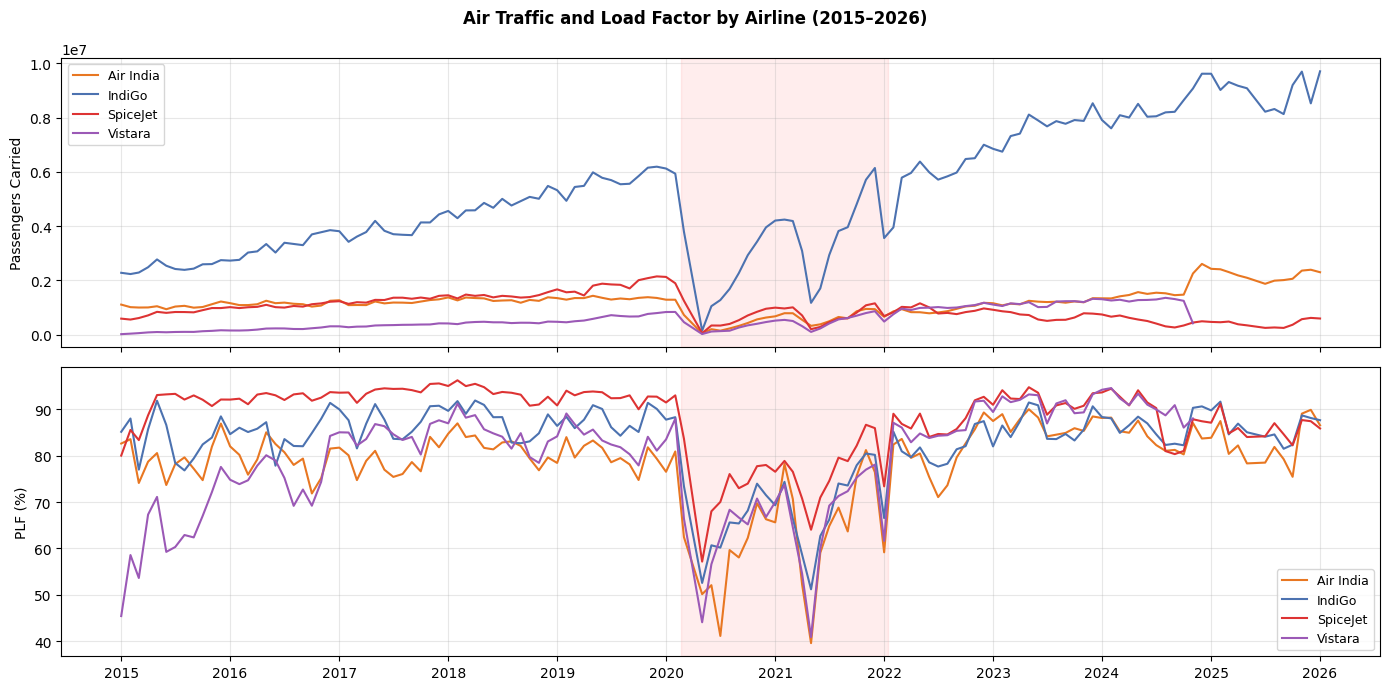

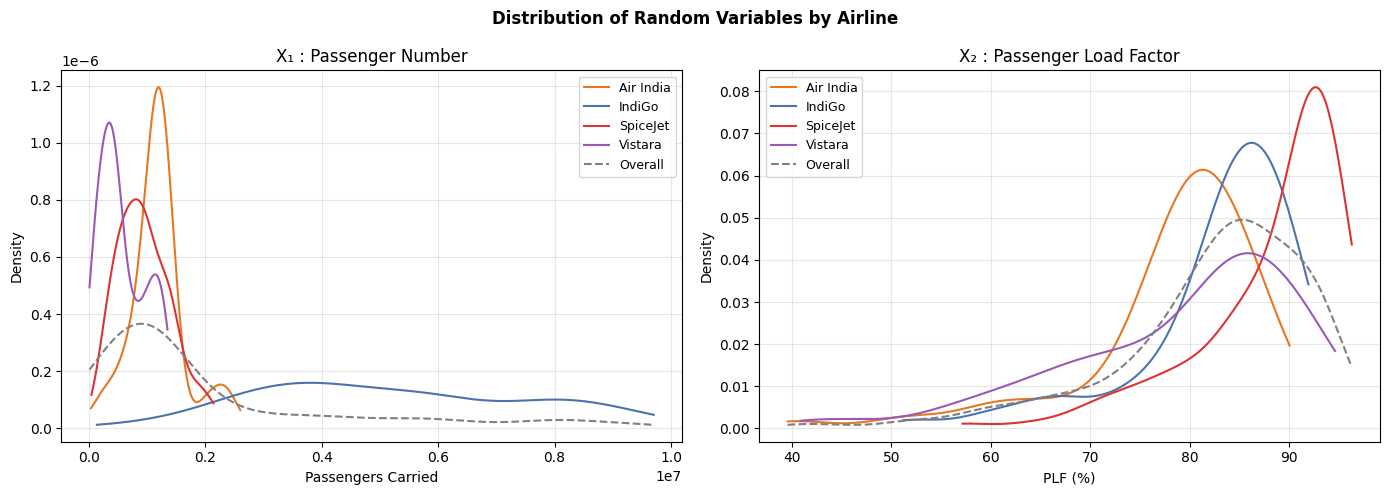

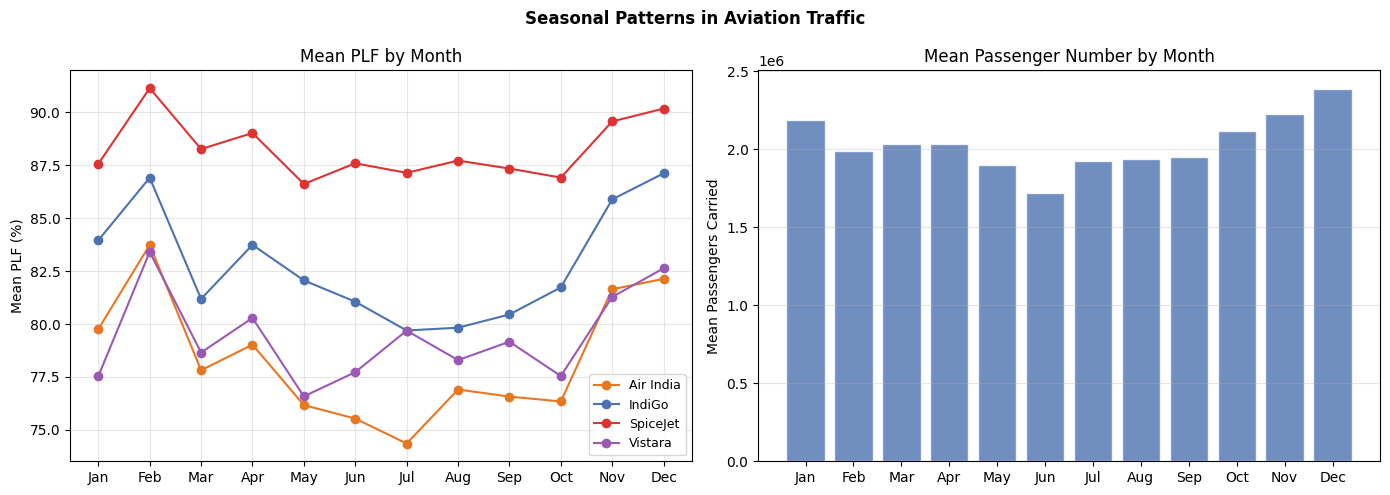

In [3]:
df = df_sd.copy()
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))

major = ['IndiGo', 'Air India', 'SpiceJet', 'Vistara'] # We choose these airlines due to consistent and covid data ,significant avg passenger volume
colors = {'IndiGo': '#4C72B0', 'Air India': '#E87722', 'SpiceJet': '#DD3333', 'Vistara': '#9B59B6'} # defining colors so its consistent across plots
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_major = df[df['Airline'].isin(major)].copy()
grouped = {airline: sub.sort_values('Date') for airline, sub in df_major.groupby('Airline')}

#KDE Plotting Function
def plot_kde(ax, data, label, color):
    kde = stats.gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 300)
    ax.plot(xs, kde(xs), label=label, color=color, linewidth=1.5,
            linestyle='--' if label == 'Overall' else '-')

# Time-series Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Air Traffic and Load Factor by Airline (2015–2026)', fontweight='bold')

for airline, sub in grouped.items():
    ax1.plot(sub['Date'], sub['Passenger Number'], color=colors[airline], label=airline, linewidth=1.5)
    ax2.plot(sub['Date'], sub['Passenger Load Factor'], color=colors[airline], label=airline, linewidth=1.5)

for ax in (ax1, ax2):
    ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2022-1-15'), color='red', alpha=0.07) #covid region
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

ax1.set_ylabel('Passengers Carried')
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax2.set_ylabel('PLF (%)')
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# KDE distributions Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Random Variables by Airline', fontweight='bold')

for airline, sub in grouped.items():
    plot_kde(ax1, sub['Passenger Number'], airline, colors[airline])
    plot_kde(ax2, sub['Passenger Load Factor'], airline, colors[airline])

plot_kde(ax1, df_major['Passenger Number'], 'Overall', 'gray')
plot_kde(ax2, df_major['Passenger Load Factor'], 'Overall', 'gray')

ax1.set(xlabel='Passengers Carried', ylabel='Density', title='X₁ : Passenger Number')
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax2.set(xlabel='PLF (%)', ylabel='Density', title='X₂ : Passenger Load Factor')

for ax in (ax1, ax2):
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Seasonal patterns Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonal Patterns in Aviation Traffic', fontweight='bold')

for airline, sub in grouped.items():
    ax1.plot(range(1, 13), sub.groupby('Month')['Passenger Load Factor'].mean(),
             marker='o', label=airline, color=colors[airline], linewidth=1.5)

ax1.set(xticks=range(1, 13), xticklabels=months, ylabel='Mean PLF (%)', title='Mean PLF by Month')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.bar(range(1, 13), df_major.groupby('Month')['Passenger Number'].mean(),
        color='#4C72B0', alpha=0.8, edgecolor='white')
ax2.set(xticks=range(1, 13), xticklabels=months, ylabel='Mean Passengers Carried', title='Mean Passenger Number by Month')
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Time-Series**  
Passenger numbers grow steadily before 2020, collapse sharply during COVID, and recover strongly after 2022. PLF also drops during COVID but quickly returns to the 80–90% range. IndiGo clearly carries the most passengers, while low-cost carriers maintain more consistent seat occupancy.

**Distribution**  
Passenger numbers are unevenly spread, with a few very high values, which explains the skew. PLF values mostly lie between 75% and 90%, forming a fairly tight and stable range.

**Seasonality**  
Travel demand rises towards the end of the year (Dec) and dips around mid-year. PLF follows a similar pattern, peaking during high-demand months and dropping slightly in off-peak periods.

**Overall**  
Passenger demand fluctuates significantly and is sensitive to shocks like COVID, but airlines manage their capacity in a way that keeps PLF relatively stable.

## Distribution Fitting

X1 Log-Normal : μ = 6.073, σ = 0.475
X2 Normal : μ = 82.276, σ = 9.914
X2 Beta : α = 13.425, β = 2.920


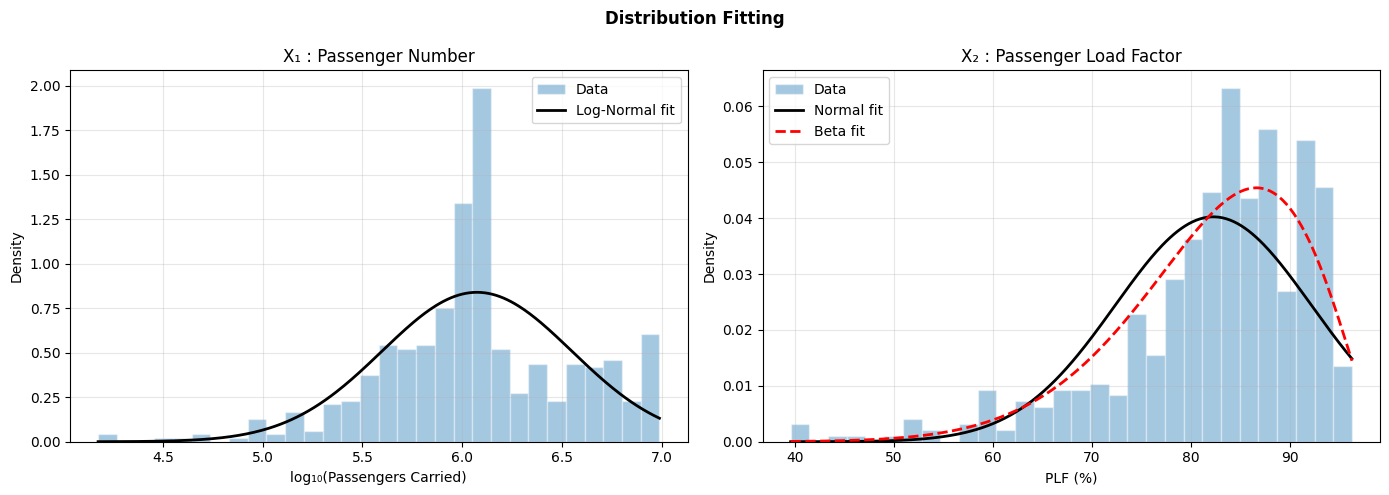

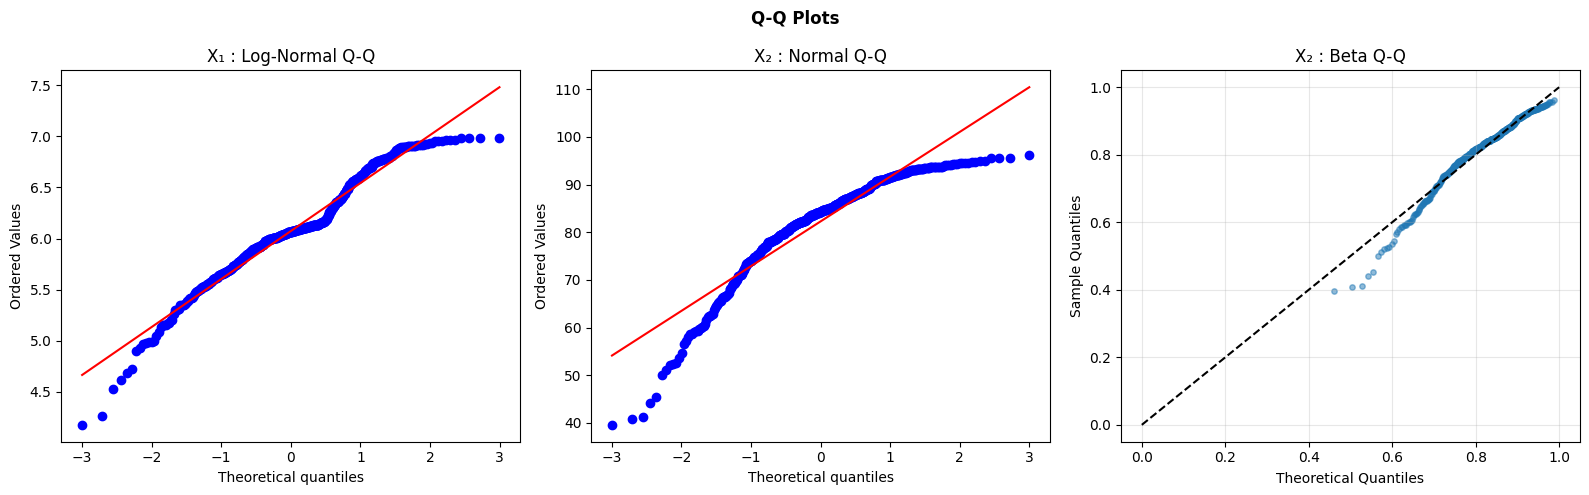

In [4]:
# Data
X1 = df_major['Passenger Number']
X2 = df_major['Passenger Load Factor']

# X1 is right-skewed (as we saw in EDA) → so considering log transform to fit log-normal
# X2 is bounded 0-100 and roughly symmetric in bulk → so considering Normal and Beta 
log_X1 = np.log10(X1)
X2_scaled = X2 / 100

# Fitting
mu_x1, std_x1 = norm.fit(log_X1)
mu_x2, std_x2 = norm.fit(X2)
a, b, loc, scale = beta.fit(X2_scaled, floc=0, fscale=1)

print(f"X1 Log-Normal : μ = {mu_x1:.3f}, σ = {std_x1:.3f}")
print(f"X2 Normal : μ = {mu_x2:.3f}, σ = {std_x2:.3f}")
print(f"X2 Beta : α = {a:.3f}, β = {b:.3f}")

# Distribution Fitting Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution Fitting', fontweight='bold')

#X1 Plot
xs1 = np.linspace(log_X1.min(), log_X1.max(), 300)
ax1.hist(log_X1, bins=30, density=True, alpha=0.4, edgecolor='white', label='Data') # histogram
ax1.plot(xs1, norm.pdf(xs1, mu_x1, std_x1), 'k-', linewidth=2, label='Log-Normal fit') # log-normal 
ax1.set(xlabel='log₁₀(Passengers Carried)', ylabel='Density', title='X₁ : Passenger Number')
ax1.legend()
ax1.grid(alpha=0.3)

xs2 = np.linspace(X2.min(), X2.max(), 300)
ax2.hist(X2, bins=30, density=True, alpha=0.4, edgecolor='white', label='Data') # histogram
ax2.plot(xs2, norm.pdf(xs2, mu_x2, std_x2), 'k-', linewidth=2, label='Normal fit') # normal
ax2.plot(xs2, beta.pdf(xs2 / 100, a, b) / 100, 'r--', linewidth=2, label='Beta fit') # beta
ax2.set(xlabel='PLF (%)', ylabel='Density', title='X₂ : Passenger Load Factor')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Q-Q Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q-Q Plots', fontweight='bold')

# X1 log-normal fit
stats.probplot(log_X1, dist='norm', plot=axes[0])
axes[0].set_title('X₁ : Log-Normal Q-Q')

# X2 Normal fit
stats.probplot(X2, dist='norm', plot=axes[1])
axes[1].set_title('X₂ : Normal Q-Q')

# X2 Beta fit
X2s_sorted = np.sort(X2_scaled)
n = len(X2s_sorted)
theoretical = beta.ppf((np.arange(n) + 0.5) / n, a, b)
axes[2].scatter(theoretical, X2s_sorted, alpha=0.5, s=15)
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1.5)
axes[2].set(xlabel='Theoretical Quantiles', ylabel='Sample Quantiles', title='X₂ : Beta Q-Q')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Passenger Number (X₁)**

* The data is right-skewed, but becomes fairly symmetric after taking logs.
* The Q–Q plot fits well in the middle, with some deviation in the extremes.
  → Overall, a log-normal distribution is a reasonable approximation, though not perfect.

**Passenger Load Factor (X₂)**  

* Most values lie between 75–90%, with a clear upper limit.
* The normal Q–Q plot shows noticeable curvature, indicating a poor fit.
* The beta Q–Q plot aligns much better with the data.
  → A beta distribution is more appropriate than a normal distribution.

**Overall**  
Passenger numbers behave roughly log-normal with some tail deviations, while PLF is better modeled using a beta distribution because of its bounded nature.

## Hypothesis Testing

**H1 : IndiGo vs Air India PLF**
- Null (H0) : μ_IndiGo ≤ μ_AirIndia
- Alternate (H1) : μ_IndiGo > μ_AirIndia
- Test : One-tailed two-sample t-test

**H2 : Post-COVID PLF Recovery**
- Null (H0) : μ_post ≤ μ_pre
- Alternate (H1) : μ_post > μ_pre
- Test : One-tailed two-sample t-test

**H3 : LCC vs FSC PLF Variance**
- Null (H0) : σ²_LCC ≥ σ²_FSC
- Alternate (H1) : σ²_LCC < σ²_FSC
- Test : One-tailed F-test

H1 : IndiGo mean = 82.82% | Air India mean = 78.36%
t = 4.1294, p = 2.45e-05 → Reject H0

H2 : Pre-COVID mean = 84.28% | Post-COVID mean = 86.06%
t = 2.5619, p = 5.38e-03 → Reject H0

H3 : LCC std = 8.24% | FSC std = 10.40%
F = 0.6277, p = 1.09e-04 → Reject H0


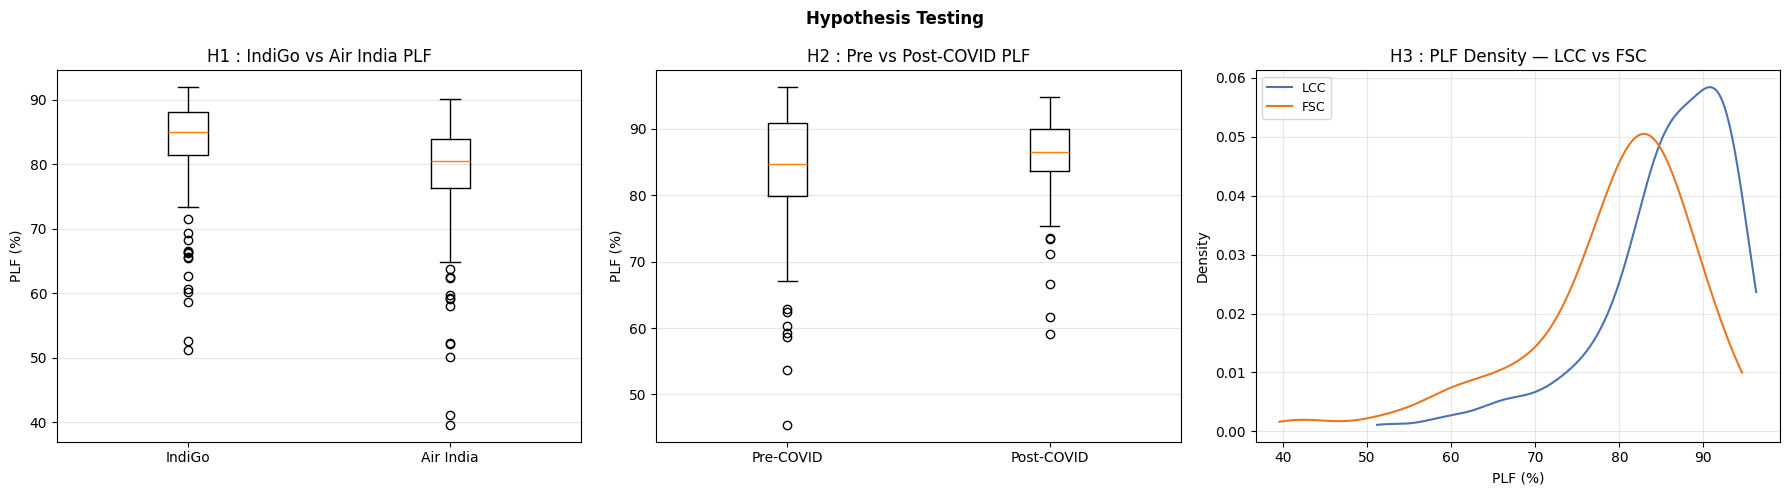

In [5]:
# Data
indigo = grouped['IndiGo']['Passenger Load Factor']
air_india = grouped['Air India']['Passenger Load Factor']
spicejet = grouped['SpiceJet']['Passenger Load Factor']
vistara = grouped['Vistara']['Passenger Load Factor']

pre_covid = df_major[df_major['Period'] == 'Pre-COVID']['Passenger Load Factor']
post_covid = df_major[df_major['Period'] == 'Post-COVID']['Passenger Load Factor']

lcc = pd.concat([indigo, spicejet])
fsc = pd.concat([air_india, vistara])

# H1 : IndiGo mean PLF > Air India mean PLF
t1, p1 = stats.ttest_ind(indigo, air_india, alternative='greater')
print(f"H1 : IndiGo mean = {indigo.mean():.2f}% | Air India mean = {air_india.mean():.2f}%")
print(f"t = {t1:.4f}, p = {p1:.2e} → {'Reject H0' if p1 < 0.05 else 'Fail to reject H0'}")

# H2 : Post-COVID PLF has recovered to Pre-COVID levels
t2, p2 = stats.ttest_ind(post_covid, pre_covid, alternative='greater')
print(f"\nH2 : Pre-COVID mean = {pre_covid.mean():.2f}% | Post-COVID mean = {post_covid.mean():.2f}%")
print(f"t = {t2:.4f}, p = {p2:.2e} → {'Reject H0' if p2 < 0.05 else 'Fail to reject H0'}")

# H3 : LCC PLF variance < FSC PLF variance
f_stat = lcc.var() / fsc.var()
p3 = stats.f.cdf(f_stat, len(lcc)-1, len(fsc)-1)
print(f"\nH3 : LCC std = {lcc.std():.2f}% | FSC std = {fsc.std():.2f}%")
print(f"F = {f_stat:.4f}, p = {p3:.2e} → {'Reject H0' if p3 < 0.05 else 'Fail to reject H0'}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hypothesis Testing', fontweight='bold')

axes[0].boxplot([indigo, air_india], tick_labels=['IndiGo', 'Air India'])
axes[0].set(title='H1 : IndiGo vs Air India PLF', ylabel='PLF (%)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot([pre_covid, post_covid], tick_labels=['Pre-COVID', 'Post-COVID'])
axes[1].set(title='H2 : Pre vs Post-COVID PLF', ylabel='PLF (%)')
axes[1].grid(axis='y', alpha=0.3)

plot_kde(axes[2], lcc, 'LCC', '#4C72B0')
plot_kde(axes[2], fsc, 'FSC', '#E87722')
axes[2].set(title='H3 : PLF Density — LCC vs FSC', xlabel='PLF (%)', ylabel='Density')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

H1 shows IndiGo’s average PLF is significantly higher than Air India’s.  
H2 shows Post-COVID PLF is significantly higher than pre-COVID levels, indicating recovery.  
H3 shows Low-cost carriers have significantly lower PLF variability, indicating more consistent operations than full-service carriers.

## Correlation Analysis

Overall : r = 0.2179, p = 6.78e-07
Overall (log) : r = 0.4473, p = 1.85e-26
Air India : r = 0.8071, p = 2.58e-31
IndiGo : r = 0.6085, p = 1.27e-14
SpiceJet : r = 0.6619, p = 7.47e-18
Vistara : r = 0.7967, p = 6.54e-27


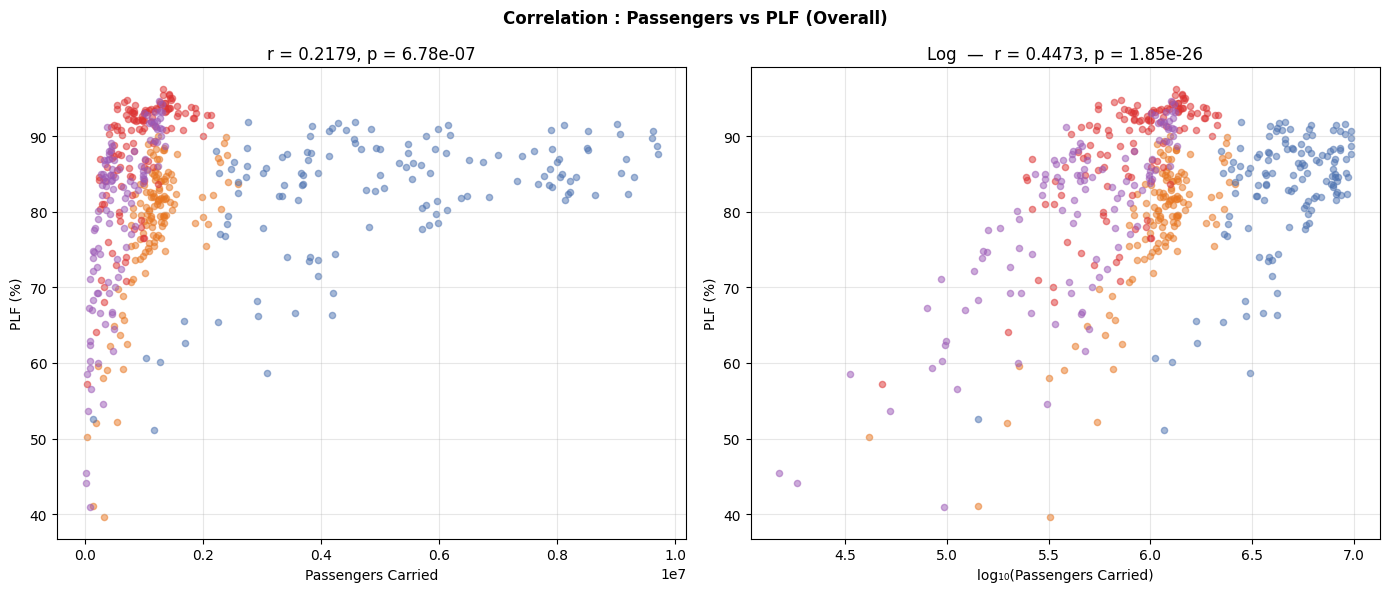

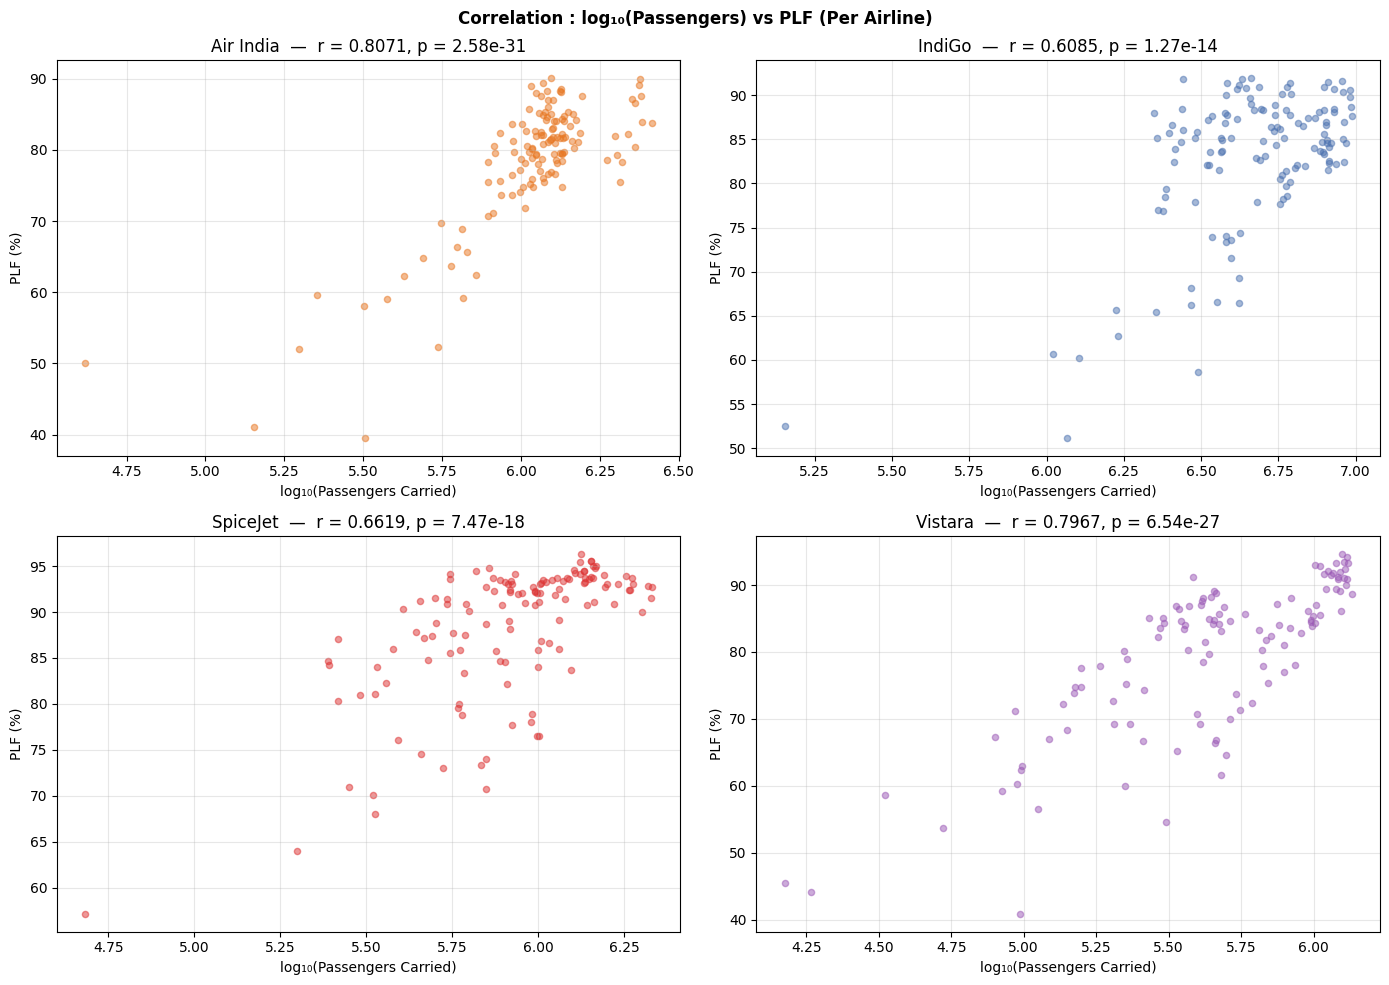

In [6]:
# Correlation Analysis
# X1 : Passenger Number, X2 : Passenger Load Factor
x, y = X1 , X2

r, p = stats.pearsonr(x, y)
r_log, p_log = stats.pearsonr(np.log10(x), y)
print(f"Overall : r = {r:.4f}, p = {p:.2e}")
print(f"Overall (log) : r = {r_log:.4f}, p = {p_log:.2e}")

# Per airline correlation
for airline, sub in grouped.items():
    r_a, p_a = stats.pearsonr(np.log10(sub['Passenger Number']), sub['Passenger Load Factor'])
    print(f"{airline} : r = {r_a:.4f}, p = {p_a:.2e}")

# Overall vs log comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation : Passengers vs PLF (Overall)', fontweight='bold')

for airline, sub in grouped.items():
    ax1.scatter(sub['Passenger Number'], sub['Passenger Load Factor'],
                alpha=0.5, color=colors[airline], s=20)
    ax2.scatter(np.log10(sub['Passenger Number']), sub['Passenger Load Factor'],
                alpha=0.5, color=colors[airline], s=20)

ax1.set(xlabel='Passengers Carried', ylabel='PLF (%)',
        title=f'r = {r:.4f}, p = {p:.2e}')
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

ax2.set(xlabel='log₁₀(Passengers Carried)', ylabel='PLF (%)',
        title=f'Log  —  r = {r_log:.4f}, p = {p_log:.2e}')

for ax in (ax1, ax2):
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Per Airline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Correlation : log₁₀(Passengers) vs PLF (Per Airline)', fontweight='bold')
axes = axes.flatten()

for i, (airline, sub) in enumerate(grouped.items()):
    r_a, p_a = stats.pearsonr(np.log10(sub['Passenger Number']),
                              sub['Passenger Load Factor'])

    axes[i].scatter(np.log10(sub['Passenger Number']),
                    sub['Passenger Load Factor'],
                    alpha=0.5, color=colors[airline], s=20)

    axes[i].set(xlabel='log₁₀(Passengers Carried)', ylabel='PLF (%)',
                title=f'{airline}  —  r = {r_a:.4f}, p = {p_a:.2e}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

* The relationship between passenger numbers and PLF is quite weak in the raw scale (r ≈ 0.22), but becomes noticeably stronger after taking log(X1) (r ≈ 0.45).

* This suggests that using log(passengers) captures the relationship more realistically, which aligns with the log-normal nature of the data.

* When we look at individual airlines, the relationship becomes much clearer:
  Air India and Vistara show strong positive correlation, while IndiGo and SpiceJet show moderate to strong correlation.

* This also shows that combining all airlines hides important differences, since each airline operates under different conditions.

Overall, using log-transformed passenger numbers gives a better picture, and analysing airlines separately is more meaningful than pooling everything together.

## Regression Analysis

Per-Airline Regression Results:

IndiGo
slope = 9.5712, CI = [7.3967, 11.7458], p = 1.27e-14
intercept = 70.8693, CI = [67.9287, 73.8100], p = 8.64e-84
r² = 0.370, Adjusted r² = 0.365, MSE = 42.785
Slope and intercept are significant → passenger volume has a measurable effect on PLF

Air India
slope = 14.9790, CI = [13.0705, 16.8876], p = 2.58e-31
intercept = 79.6694, CI = [78.7086, 80.6303], p = 1.30e-151
r² = 0.651, Adjusted r² = 0.649, MSE = 29.963
Slope and intercept are significant → passenger volume has a measurable effect on PLF

SpiceJet
slope = 9.0886, CI = [7.2956, 10.8816], p = 7.47e-18
intercept = 91.2489, CI = [90.1258, 92.3720], p = 1.76e-150
r² = 0.438, Adjusted r² = 0.434, MSE = 30.525
Slope and intercept are significant → passenger volume has a measurable effect on PLF

Vistara
slope = 10.8714, CI = [9.3481, 12.3946], p = 6.54e-27
intercept = 89.4798, CI = [87.5652, 91.3943], p = 7.65e-110
r² = 0.635, Adjusted r² = 0.632, MSE = 49.369
Slope and intercept are significan

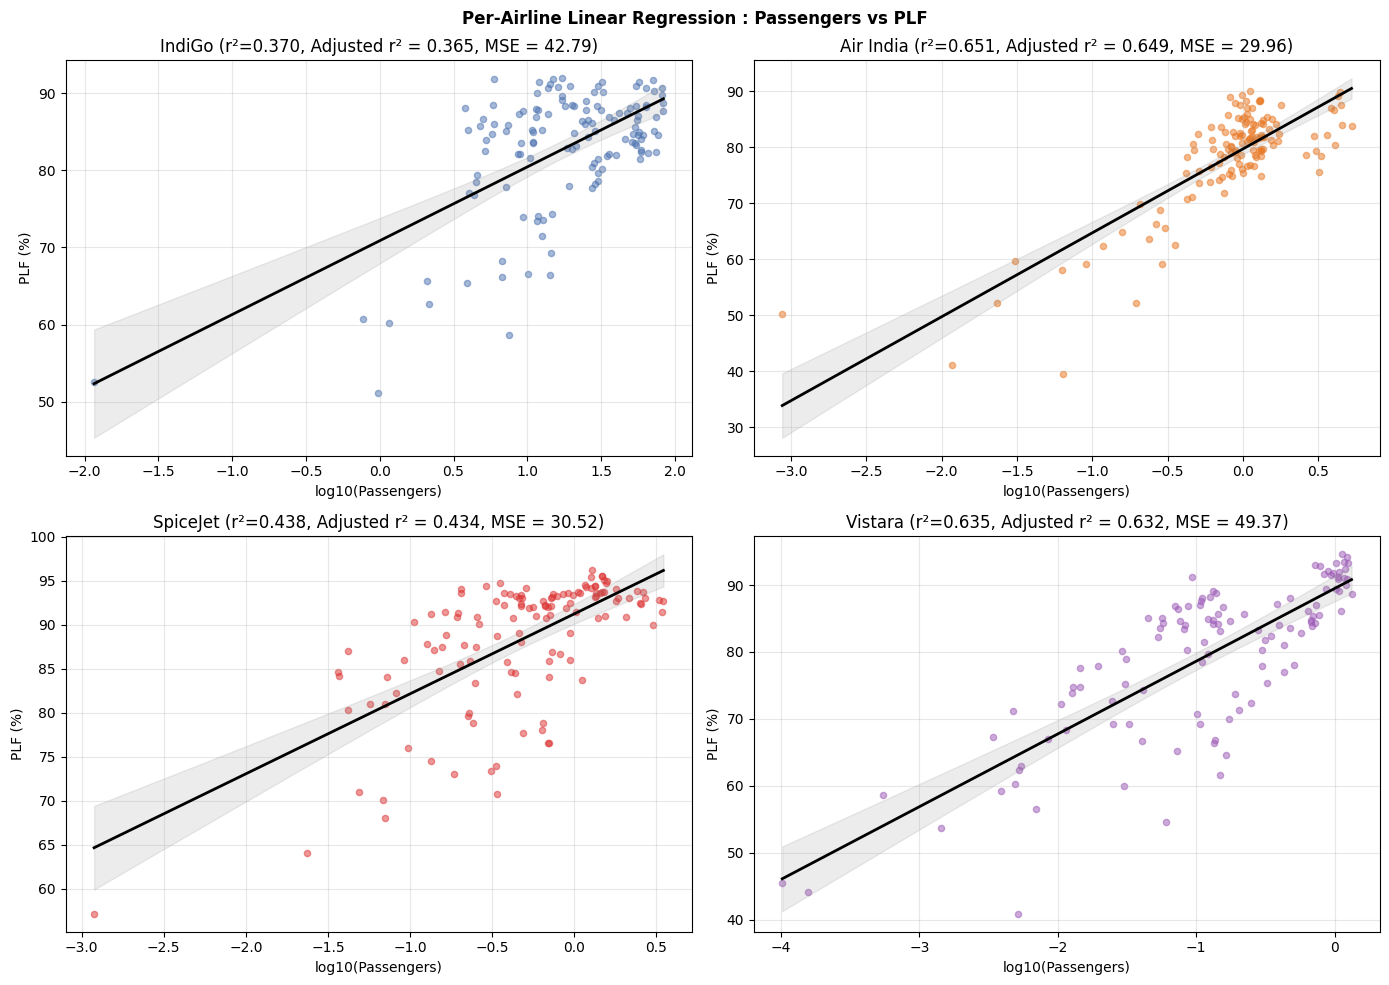

In [7]:
# Per-airline Linear Regression : X1 (Passengers) vs X2 (PLF)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Per-Airline Linear Regression : Passengers vs PLF', fontweight='bold')
axes = axes.flatten()

# Pooled standardisation so the coefficients can be compared 
log_X1_all = np.log10(df_major['Passenger Number'].dropna())
pool_mean, pool_std = log_X1_all.mean(), log_X1_all.std()

print("Per-Airline Regression Results:")

for i, airline in enumerate(major):
    sub = grouped[airline].dropna(subset=['Passenger Number', 'Passenger Load Factor'])

    x_std = (np.log10(sub['Passenger Number']) - pool_mean) / pool_std # standardisation
    y = sub['Passenger Load Factor']

    # Model Fitting
    model = sm.OLS(y, sm.add_constant(x_std)).fit() # OLS fit

    slope = model.params.iloc[1]
    intercept = model.params.iloc[0]
    ci = model.conf_int()
    p_slope = model.pvalues.iloc[1]
    p_intercept = model.pvalues.iloc[0]
    
    #Metrics
    r2 = model.rsquared
    r2_adj = model.rsquared_adj
    mse = model.mse_resid

    print(f"\n{airline}")
    print(f"slope = {slope:.4f}, CI = [{ci.iloc[1,0]:.4f}, {ci.iloc[1,1]:.4f}], p = {p_slope:.2e}")
    print(f"intercept = {intercept:.4f}, CI = [{ci.iloc[0,0]:.4f}, {ci.iloc[0,1]:.4f}], p = {p_intercept:.2e}")
    print(f"r² = {r2:.3f}, Adjusted r² = {r2_adj:.3f}, MSE = {mse:.3f}")
    if ((p_slope < 0.05) & (p_intercept < 0.05)):
      print("Slope and intercept are significant → passenger volume has a measurable effect on PLF")
    else:
      print("Slope and intercept are not significant → no strong relationship between passengers and PLF")

    # Plot
    ax = axes[i]
    xs = np.linspace(x_std.min(), x_std.max(), 300)
    X_pred = pd.DataFrame({'const': 1, 'log_passengers': xs})
    pred = model.get_prediction(X_pred).conf_int()

    ax.scatter(x_std, y, color=colors[airline], alpha=0.5, s=20)
    ax.plot(xs, slope * xs + intercept, 'k-', linewidth=2)
    ax.fill_between(xs, pred[:,0], pred[:,1], alpha=0.15, color='gray')

    ax.set(title=f'{airline} (r²={r2:.3f}, Adjusted r² = {r2_adj:.3f}, MSE = {mse:.2f})',
           xlabel='log10(Passengers)',
           ylabel='PLF (%)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

* Across all airlines, higher passenger numbers are clearly associated with higher PLF, and this relationship is statistically significant.
* The relationship is stronger for Air India and Vistara (r² ≈ 0.63–0.65), while IndiGo and SpiceJet show a more moderate fit (r² ≈ 0.37–0.44), suggesting greater variability in their operations.
* In simple terms, more demand generally leads to better seat utilisation, but how consistent this effect is varies by airline.

The moderate fit for some airlines shows that passenger numbers alone don’t explain PLF completely.

### Performed Multiple Linear Regression including Period and Month categorical variables

Per-Airline Regression Results:

IndiGo: r² = 0.839, Adjusted r² = 0.820, MSE = 12.127

Air India: r² = 0.754, Adjusted r² = 0.724, MSE = 23.522

SpiceJet: r² = 0.802, Adjusted r² = 0.778, MSE = 11.962

Vistara: r² = 0.855, Adjusted r² = 0.835, MSE = 22.101


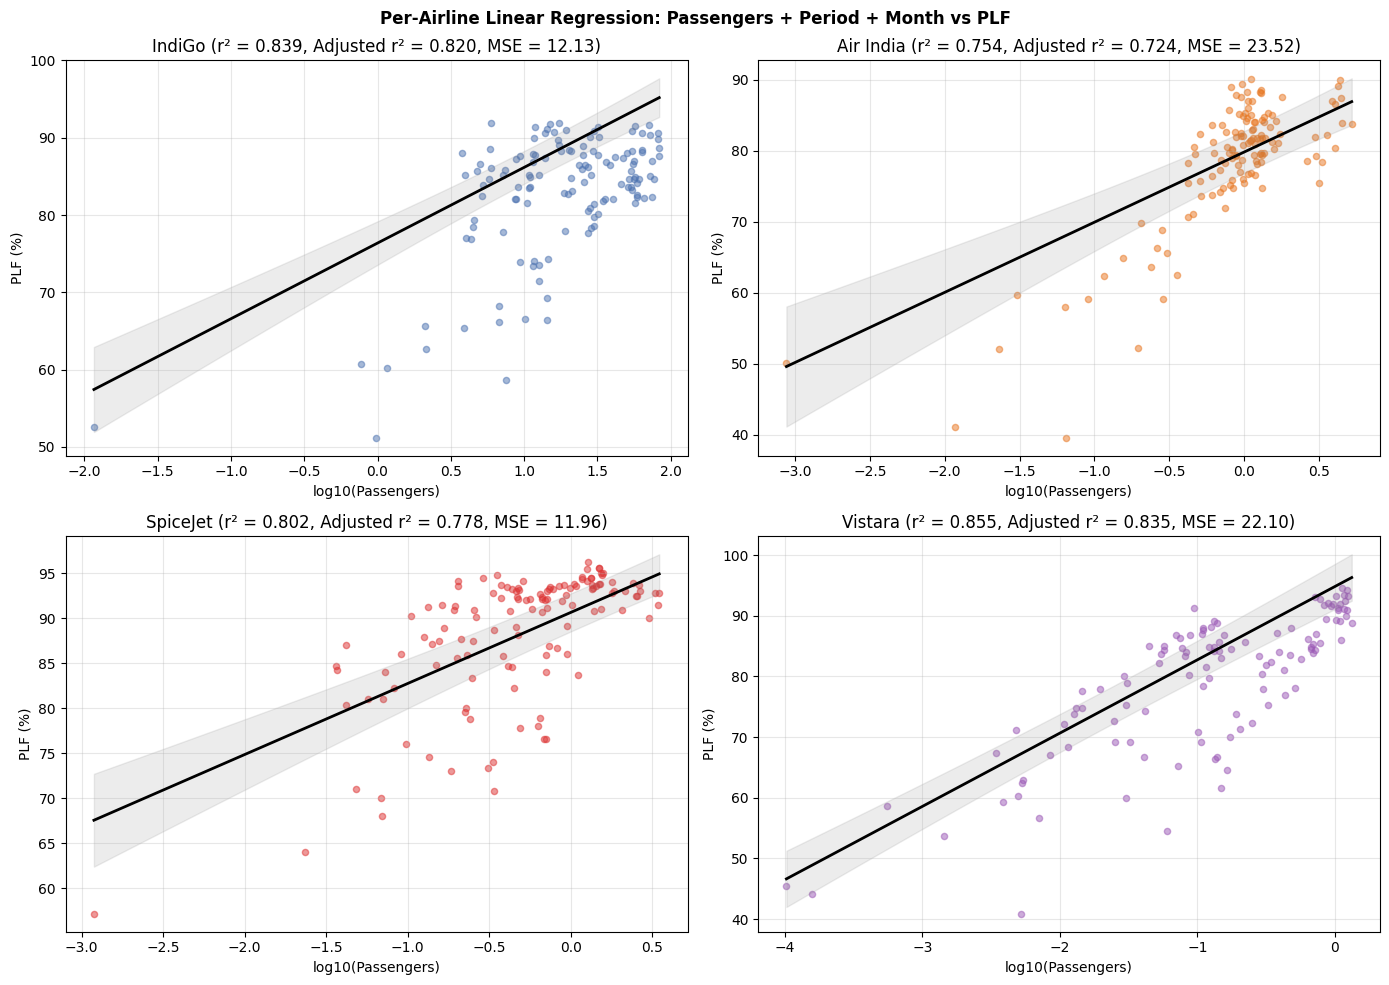

In [8]:
# Per-airline Multiple Linear Regression: Passengers + Period + Month vs PLF
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Per-Airline Linear Regression: Passengers + Period + Month vs PLF', fontweight='bold')
axes = axes.flatten()

print("Per-Airline Regression Results:")

for i, airline in enumerate(major):
    sub = grouped[airline].dropna(subset=['Passenger Number', 'Passenger Load Factor', 'Period', 'Month'])

    x_std = (np.log10(sub['Passenger Number']) - pool_mean) / pool_std
    y = sub['Passenger Load Factor']

    period_dummies = pd.get_dummies(sub['Period'], drop_first=False).drop(columns='Pre-COVID').astype(float)
    month_dummies = pd.get_dummies(sub['Month'], drop_first=False).drop(columns=1).astype(float)
    month_dummies.columns = [months[int(m) - 1] for m in month_dummies.columns]

    X = pd.concat([x_std.rename('log_passengers'), period_dummies, month_dummies], axis=1)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    r2 = model.rsquared
    r2_adj = model.rsquared_adj
    mse = model.mse_resid

    print(f"\n{airline}: r² = {r2:.3f}, Adjusted r² = {r2_adj:.3f}, MSE = {mse:.3f}")

    xs = np.linspace(x_std.min(), x_std.max(), 300)
    X_pred = pd.DataFrame({
        'const': 1,
        'log_passengers': xs,
        **{col: 0.0 for col in period_dummies.columns},
        **{col: 0.0 for col in month_dummies.columns}
    })

    pred = model.get_prediction(X_pred).conf_int()
    slope = model.params['log_passengers']
    intercept = model.params['const']

    ax = axes[i]
    ax.scatter(x_std, y, color=colors[airline], alpha=0.5, s=20)
    ax.plot(xs, slope * xs + intercept, 'k-', linewidth=2)
    ax.fill_between(xs, pred[:, 0], pred[:, 1], alpha=0.15, color='gray')
    ax.set(
        title=f'{airline} (r² = {r2:.3f}, Adjusted r² = {r2_adj:.3f}, MSE = {mse:.2f})',
        xlabel='log10(Passengers)',
        ylabel='PLF (%)'
    )
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Including Period and Month clearly makes the model much better.

* The fit improves noticeably (r² goes up to around 0.75–0.86) and errors reduce
* Passenger volume still matters, but it’s not the whole story
* Seasonal patterns and COVID disruptions have a strong impact on PLF

Across airlines:

* IndiGo and SpiceJet are explained well by the model
* Vistara shows the most consistent pattern
* Air India improves, but still has more variation left unexplained

Overall, PLF isn’t driven by demand alone. It also depends on timing and external shocks, which is why the multivariate model works better than the simple one.